In [ ]:
# Install required libraries (run once)
!pip install librosa matplotlib numpy soundfile

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load audio file
# y = waveform (amplitude values)
# sr = sample rate (samples per second)
audio_path = "./audio_file.mp3"
y, sr = librosa.load(audio_path, sr=16000)

# Inspect signal properties
print(f"Sample Rate: {sr}")
print(f"Duration: {len(y)/sr:.2f} seconds")
print(f"Waveform Shape: {y.shape}")

Sample Rate: 16000
Duration: 42.01 seconds
Waveform Shape: (672134,)


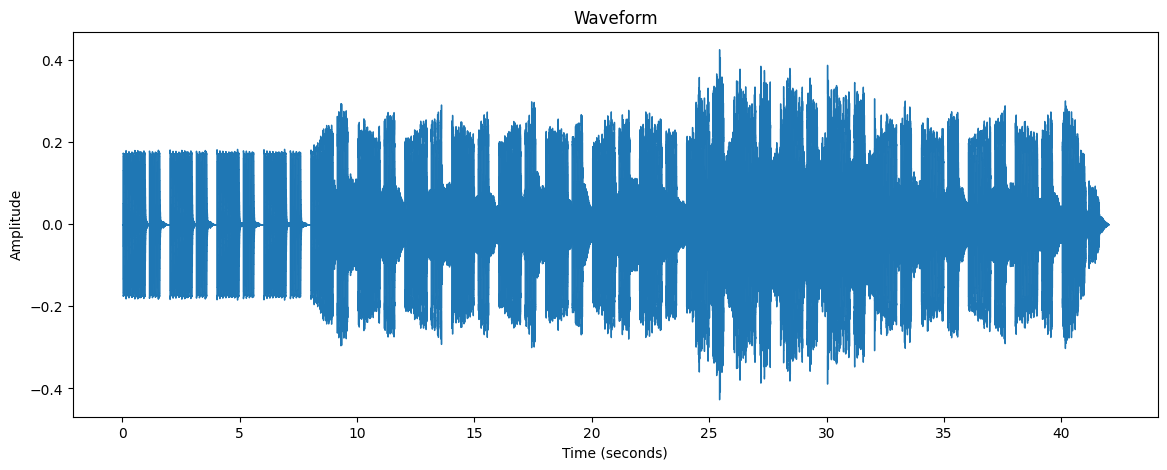

In [ ]:
# Plot waveform to visualize amplitude over time
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

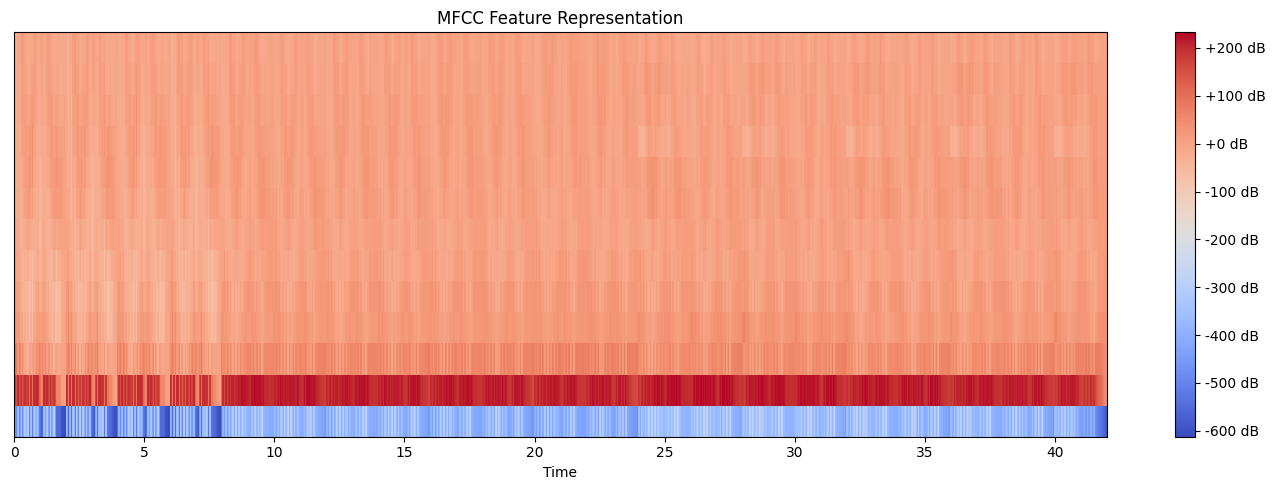

In [ ]:
# MFCCs capture speech-relevant frequency information
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(14, 5))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title("MFCC Feature Representation")
plt.tight_layout()
plt.show()

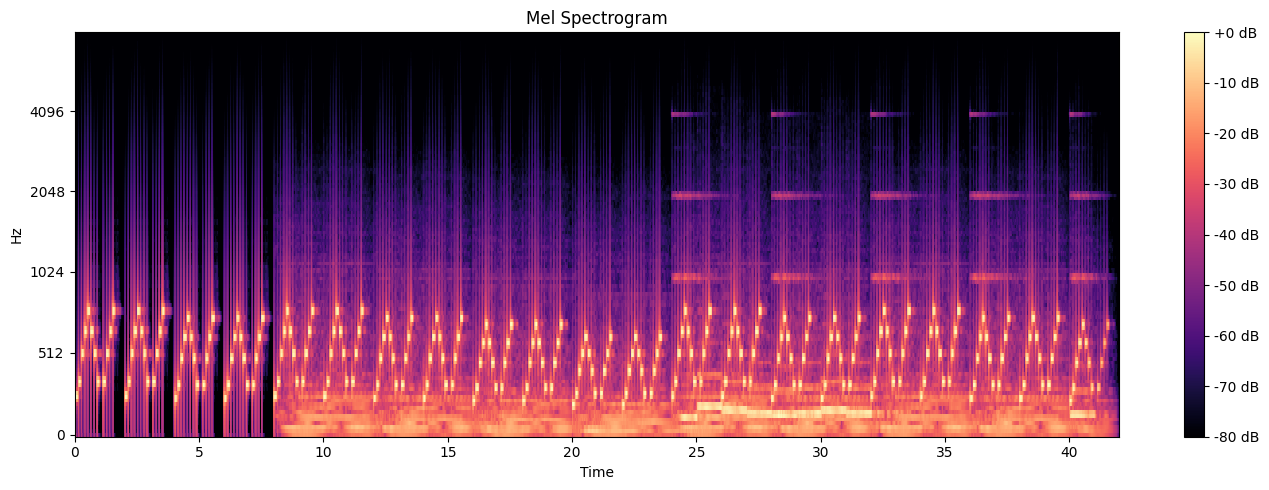

In [ ]:
# Mel Spectrogram: time-frequency energy map
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    mel_spec_db, sr=sr, x_axis='time', y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

In [ ]:
# Install Whisper
!pip install openai-whisper ffmpeg-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 12.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 5.8 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=400292573904699a56ecf2ad83c1645a6cbc61f79279f5ec533f9a4dc827595e
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:
import whisper

# Load Whisper model (first run downloads weights)
model = whisper.load_model("base")

# Transcribe audio file
result = model.transcribe("./audio_file.mp3")

print("Transcription:")
print(result["text"])

print("Detected Language:", result["language"])

100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 80.1MiB/s]
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Transcription:
 Sust a un pic si Tatăriilos I don't care dintr-u atireat I black belt
Detected Language: ro


In [ ]:
# Transcription with timestamps
result = model.transcribe(
    "./harvard.wav",
    word_timestamps=True
)

for segment in result["segments"]:
    print(f"[{segment['start']:.2f}s - {segment['end']:.2f}s] {segment['text']}")

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


[0.86s - 3.64s]  The stale smell of old beer lingers.
[4.18s - 6.18s]  It takes heat to bring out the odor.
[7.02s - 9.16s]  A cold dip restores health and zest.
[9.96s - 12.00s]  A salt pickle tastes fine with ham.
[12.68s - 14.32s]  Tacos al pastor are my favorite.
[15.12s - 17.42s]  A zestful food is the hot cross bun.


In [ ]:
# Multilingual transcription
spanish = model.transcribe("./SPFemale_BlancaM.mp3", language="es")
print("Spanish:", spanish["text"])

# Translation to English
translated = model.transcribe("./SPFemale_BlancaM.mp3", task="translate")
print("English Translation:", translated["text"])

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Spanish:  Bienvenido una vez más al curso de Toyota sobre el plan de Fidelización, hasta ahora ya has visto el WorldCompac IMGM. En este ejemplo seleccionamos el evento obtener signos vitales de la categoría valoración. Al pulsar en estos eventos se abre una ventana con varias opciones. En este caso, temperatura, pulso, presión sanguínea y frecuencia respiratoria.


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


English Translation:  Welcome again to the Toyota course on the Fidelization Plan, until now you have seen the GWD and MGM. In this example, we select the event of having vital signals from the Valoración category. In this event, this event will open a window with several options. In this case, temperature, pulse, pressure, sanguina and respiratory frequency.


In [ ]:
!pip install noisereduce

In [ ]:
import librosa
import whisper
import noisereduce as nr
import soundfile as sf
import re

class AudioPipeline:
    def __init__(self, model_size="base"):
        self.model = whisper.load_model(model_size)

    def preprocess_audio(self, audio_path):
        # Load and resample
        y, sr = librosa.load(audio_path, sr=16000)

        # Noise reduction improves ASR robustness
        y = nr.reduce_noise(y=y, sr=sr)

        # Normalize loudness
        y = librosa.util.normalize(y)

        return y, sr

    def transcribe(self, audio_path):
        audio, sr = self.preprocess_audio(audio_path)

        temp_file = "./harvard.wav"
        sf.write(temp_file, audio, sr)

        result = self.model.transcribe(temp_file)
        return result["text"]

    def postprocess_text(self, text):
        if not text:
            return text

        text = text.strip()
        text = text[0].upper() + text[1:]

        if text[-1] not in ".!?":
            text += "."

        text = re.sub(r"\s+", " ", text)
        return text

    def process_audio(self, audio_path):
        print("Processing audio...")
        raw = self.transcribe(audio_path)
        print("Raw:", raw)

        final = self.postprocess_text(raw)
        print("Final:", final)
        return final

In [ ]:
# Run full pipeline
pipeline = AudioPipeline(model_size="base")
final_text = pipeline.process_audio("./harvard.wav")
print("Pipeline Output:", final_text)

Processing audio...


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Raw:  The stale smell of cold beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with it. Tacos al pastor are my favorite. A zestful food is the hot cross bun.
Final: The stale smell of cold beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with it. Tacos al pastor are my favorite. A zestful food is the hot cross bun.
Pipeline Output: The stale smell of cold beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with it. Tacos al pastor are my favorite. A zestful food is the hot cross bun.


In [ ]:
### Exercise Tasks

###**1. Test with different audio qualities:
 ###  - Clean studio recording

  # - Phone call recording
   #- Noisy environment recording

#2. **Compare preprocessing effects**:
 #  - Run with and without noise reduction
  # - Measure accuracy differences

#3. **Add custom post-processing**:
 #  - Number formatting ("twenty five" → "25")
  # - Date formatting
   #- Custom vocabulary (acronyms, company names)**

In [ ]:
import time
import numpy as np
import whisper
import librosa

def calculate_wer(reference, hypothesis):
    ref = reference.lower().split()
    hyp = hypothesis.lower().split()

    d = np.zeros((len(ref)+1, len(hyp)+1))
    for i in range(len(ref)+1):
        d[i][0] = i
    for j in range(len(hyp)+1):
        d[0][j] = j

    for i in range(1, len(ref)+1):
        for j in range(1, len(hyp)+1):
            if ref[i-1] == hyp[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                d[i][j] = min(
                    d[i-1][j] + 1,
                    d[i][j-1] + 1,
                    d[i-1][j-1] + 1
                )
    return d[len(ref)][len(hyp)] / len(ref) * 100

In [ ]:
def evaluate_model(model_name, audio_file, reference):
    print(f"\nTesting model: {model_name}")
    start = time.time()
    model = whisper.load_model(model_name)
    load_time = time.time() - start

    y, sr = librosa.load(audio_file, sr=16000)
    duration = len(y) / sr

    start = time.time()
    result = model.transcribe(audio_file)
    transcribe_time = time.time() - start

    wer = calculate_wer(reference, result["text"])
    rtf = transcribe_time / duration

    return {
        "model": model_name,
        "load_time": load_time,
        "rtf": rtf,
        "wer": wer
    }

In [ ]:
audio_file = "./harvard.wav"
reference = "the quick brown fox jumps over the lazy dog"

models = ["tiny", "base", "small"]
results = []

for m in models:
    results.append(evaluate_model(m, audio_file, reference))

for r in results:
    print(r)


Testing model: tiny


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Testing model: base


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Testing model: small


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


{'model': 'tiny', 'load_time': 0.6037421226501465, 'rtf': 0.19842722564479062, 'wer': np.float64(455.55555555555554)}
{'model': 'base', 'load_time': 1.1935930252075195, 'rtf': 0.2958931044571084, 'wer': np.float64(455.55555555555554)}
{'model': 'small', 'load_time': 5.636834383010864, 'rtf': 0.9808741859485391, 'wer': np.float64(455.55555555555554)}


In [ ]:
import time
import librosa
import whisper
import soundfile as sf
import numpy as np
import pandas as pd
import re

# -----------------------------
# Utility: Text normalization
# -----------------------------
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# -----------------------------
# Utility: Word Error Rate
# -----------------------------
def wer(reference, hypothesis):
    ref_words = reference.split()
    hyp_words = hypothesis.split()

    d = np.zeros((len(ref_words) + 1, len(hyp_words) + 1))

    for i in range(len(ref_words) + 1):
        d[i][0] = i
    for j in range(len(hyp_words) + 1):
        d[0][j] = j

    for i in range(1, len(ref_words) + 1):
        for j in range(1, len(hyp_words) + 1):
            if ref_words[i - 1] == hyp_words[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                d[i][j] = min(
                    d[i - 1][j] + 1,     # deletion
                    d[i][j - 1] + 1,     # insertion
                    d[i - 1][j - 1] + 1  # substitution
                )

    return d[len(ref_words)][len(hyp_words)] / max(1, len(ref_words))


# -----------------------------
# Model evaluation
# -----------------------------
def evaluate_model(model_name, audio_file, reference_text):
    # Load model
    t0 = time.time()
    model = whisper.load_model(model_name)
    load_time = time.time() - t0

    # Load & resample audio
    audio, sr = librosa.load(audio_file, sr=16000)
    duration = len(audio) / sr

    # Write temp WAV (Whisper expects WAV)
    temp_wav = "temp.wav"
    sf.write(temp_wav, audio, sr)

    # Transcription
    t1 = time.time()
    result = model.transcribe(temp_wav, fp16=False)
    infer_time = time.time() - t1

    rtf = infer_time / duration

    # Normalize texts
    ref_norm = normalize_text(reference_text)
    hyp_norm = normalize_text(result["text"])

    wer_score = wer(ref_norm, hyp_norm) * 100  # percentage

    return {
        "Model": model_name,
        "Load Time (s)": round(load_time, 2),
        "RTF": round(rtf, 2),
        "WER (%)": round(wer_score, 2)
    }


# -----------------------------
# Run experiment
# -----------------------------
audio_file = "audio_file.mp3"
reference = "the quick brown fox jumps over the lazy dog"

models = ["tiny", "base", "small"]
results = []

for m in models:
    results.append(evaluate_model(m, audio_file, reference))

df = pd.DataFrame(results)
df


,Model,Load Time (s),RTF,WER (%)
0,tiny,1.06,0.33,100.0
1,base,1.20,1.10,100.0
2,small,6.40,5.67,100.0
